## Setup

In [71]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

REPORTS_DIR = Path.cwd() / "reports"

In [72]:
palette = [
    "#0072B2",
    "#6EC6F0",
    "#1A3A6B",
    "#77D4CC",
    "#009E73",
    "#44AA99",
    "#F2E55C",
    "#E69F00",
    "#556B00",
    "#D4669A",
    "#CC3311",
    "#DDDDDD",
    "#222222",
    "#882255"
]

cmap = mcolors.ListedColormap(palette, name="custom")

## Load Reports

In [73]:
def load_reports(report_dir):
    reports = {}
    for p in report_dir.glob("*_build_status.json"):
        repo = p.stem.replace("_build_status", "")
        with p.open() as f: raw = json.load(f)
        reports[repo] = raw["report"]
    return reports

reports = load_reports(REPORTS_DIR)
print("repos:", len(reports))

repos: 3


## Convert to DataFrames

In [74]:
def flatten_totals(reports):
    rows = []
    for repo, row in reports.items():
        report = row if "totals" in row else row["report"]
        section_labels = report["labels"]["sections"]
        field_labels = report["labels"]["fields"]
        for section, metrics in report["totals"].items():
            section_label = section_labels[section]
            for metric, value in metrics.items():
                metric_label = field_labels[metric]
                rows.append({
                    "repo": repo,
                    "section": section_label,
                    "metric": metric_label,
                    "value": value
                })
        section_timing = "Timing"
        report = row if "timing" in row else row["report"]
        phase_labels = report["labels"]["phases"]
        rows.append({
            "repo": repo,
            "section": section_timing,
            "metric": field_labels["build_total_seconds"],
            "value": report["timing"]["build_total_seconds"]
        })
        rows.append({
            "repo": repo,
            "section": section_timing,
            "metric": field_labels["build_wall_seconds"],
            "value": report["timing"]["build_wall_seconds"]
        })
        for phase, time in report["timing"]["build_phase_timings"].items():
            rows.append({
                "repo": repo,
                "section": section_timing,
                "metric": phase_labels[phase],
                "value": time
            })

    return pd.DataFrame(rows)

totals_df= flatten_totals(reports)

In [75]:
def flatten_scopes(reports):
    rows = []
    for repo, row in reports.items():
        report = row if "scopes" in row else row["report"]
        section_labels = report["labels"]["sections"]
        field_labels = report["labels"]["fields"]
        scope_labels = report["labels"]["scopes"]
        for scope, sections in report["scopes"].items():
            scope_label = scope_labels[scope]
            for section, metrics in sections.items():
                section_label = section_labels[section]
                for metric, value in metrics.items():
                    metric_label = field_labels[metric]
                    rows.append({
                        "repo": repo,
                        "scope": scope_label,
                        "section": section_label,
                        "metric": metric_label,
                        "value": value
                    })

    return pd.DataFrame(rows)

scopes_df= flatten_scopes(reports)

In [76]:
def flatten_languages(reports):
    rows = []
    for repo, row in reports.items():
        report = row if "languages" in row else row["report"]
        section_labels = report["labels"]["sections"]
        field_labels = report["labels"]["fields"]
        for language, sections in report["languages"].items():
            language_label = language
            for section, metrics in sections.items():
                section_label = section_labels[section]
                for metric, value in metrics.items():
                    metric_label = field_labels[metric]
                    rows.append({
                        "repo": repo,
                        "language": language_label,
                        "section": section_label,
                        "metric": metric_label,
                        "value": value
                    })

    return pd.DataFrame(rows)

languages_df= flatten_languages(reports)

## Service functions

In [77]:
def df_section(df, section):
    subset = df[df.section == section]
    return subset.pivot(index="repo", columns="metric", values="value")

## Overview

In [78]:
totals_pivot = totals_df.pivot(
    index="repo",
    columns=["section","metric"],
    values="value")

totals_pivot

section Call Materialization                                 Callsites  \
metric        Callsite Pairs Finalized Call Edges Filtered Pre-Persist   
repo                                                                     
eslint                 649.0                648.0                 37.0   
npm-cli               5140.0               5135.0                232.0   
rollup                8362.0               8320.0               3685.0   

section                                                                      \
metric  Observed Syntactic Callsites Persisted Accepted Persisted Callsites   
repo                                                                          
eslint                         689.0              649.0               652.0   
npm-cli                       5445.0             5140.0              5213.0   
rollup                       11852.0             8123.0              8167.0   

section                         Pre-Persist Filter                            \
metric  Persisted Dropped Accepted Outside In-Repo Invalid Observation Shape   
repo                                                                           
eslint                3.0                      0.0                       0.0   
npm-cli              73.0                      0.0                       0.0   
rollup               44.0                      0.0                       0.0   

section                                      ...                    Timing  \
metric  Likely Dynamic Dispatch Or Indirect  ... Compute Build Fingerprint   
repo                                         ...                             
eslint                                  1.0  ...                  0.233772   
npm-cli                                 2.0  ...                  0.354879   
rollup                                 39.0  ...                  0.363222   

section                                                                     \
metric  Extract Call Observations Diagnostic Classification Discover Files   
repo                                                                         
eslint                   8.300337                  0.044468       0.485908   
npm-cli                 13.162699                  0.136891       0.683566   
rollup                  16.150408                  1.021081       2.643691   

section                                                                    \
metric  Prepare Callsite Pairs Prepare Snapshots Rebuild Call Graph Index   
repo                                                                        
eslint                0.026156          0.293269                 0.039602   
npm-cli               0.230739          0.298583                 0.300848   
rollup                0.911401          2.030968                 0.402472   

section                                                              
metric  Rebuild Graph Rollups Register Modules Write Callsite Pairs  
repo                                                                 
eslint               0.063404         0.452434             0.017366  
npm-cli              0.268649         0.510351             0.249091  
rollup               0.383125         5.898596             0.299456  

[3 rows x 31 columns]

In [79]:
timing_total_df = df_section(totals_df, "Timing")[["Build Wall Time"]]
timing_total_df = timing_total_df.sort_values("Build Wall Time", ascending=True)
timing_total_df = timing_total_df.join(df_section(totals_df, "Structure")[["Nodes", "Edges"]])
timing_total_df["Nodes + Edges"] = timing_total_df["Nodes"] + timing_total_df["Edges"]
timing_total_df["Time per 1K Nodes"] = timing_total_df["Build Wall Time"] / (timing_total_df["Nodes"] / 1000)
timing_total_df["Time per 1K Edges"] = timing_total_df["Build Wall Time"] / (timing_total_df["Edges"] / 1000)
timing_total_df["Time per 1K (Nodes + Edges)"] = timing_total_df["Build Wall Time"] / (timing_total_df["Nodes + Edges"] / 1000)

timing_mean = timing_total_df.mean(numeric_only=True)
timing_median = timing_total_df.median(numeric_only=True)
timing_std = timing_total_df.std(numeric_only=True)

timing_mean.name = "Mean"
timing_median.name = "Median"
timing_std.name = "Std"

timing_overview_df = pd.concat([timing_total_df, timing_mean.to_frame().T, timing_std.to_frame().T, timing_median.to_frame().T]).round(2)
timing_overview_df

metric,Build Wall Time,Nodes,Edges,Nodes + Edges,Time per 1K Nodes,Time per 1K Edges,Time per 1K (Nodes + Edges)
eslint,18.78,2905.00,2856.00,5761.00,6.46,6.58,3.26
npm-cli,NaN,9167.00,14299.00,23466.00,NaN,NaN,NaN
rollup,NaN,19557.00,20381.00,39938.00,NaN,NaN,NaN
Mean,18.78,10543.00,12512.00,23055.00,6.46,6.58,3.26
Std,NaN,8410.84,8898.11,17092.21,NaN,NaN,NaN
Median,18.78,9167.00,14299.00,23466.00,6.46,6.58,3.26


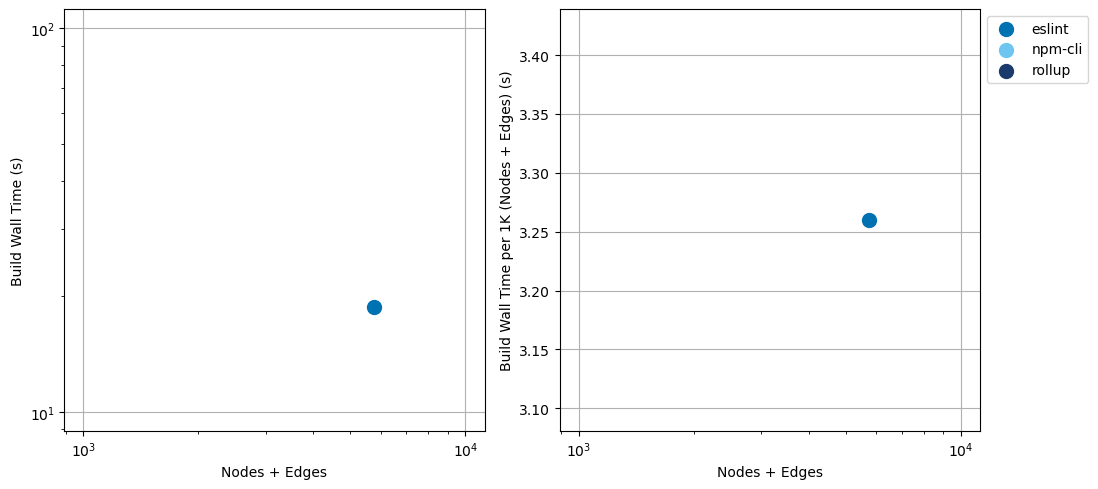

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True)

for i, repo in enumerate(timing_total_df.index):
    color = palette[i % len(palette)]
    x = timing_total_df.loc[repo, "Nodes + Edges"]
    y1 = timing_total_df.loc[repo, "Build Wall Time"]
    y2 = timing_total_df.loc[repo, "Time per 1K (Nodes + Edges)"]

    axes[0].scatter(x, y1, color=color, s=100, label=repo)
    axes[1].scatter(x, y2, color=color, s=100)

axes[0].set_xlabel("Nodes + Edges")
axes[0].set_ylabel("Build Wall Time (s)")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].grid(True)

axes[1].set_xlabel("Nodes + Edges")
axes[1].set_ylabel("Build Wall Time per 1K (Nodes + Edges) (s)")
axes[1].set_xscale("log")
axes[1].grid(True)

fig.legend(loc="upper left", bbox_to_anchor=(0.985, 0.97))
plt.tight_layout()
plt.show()

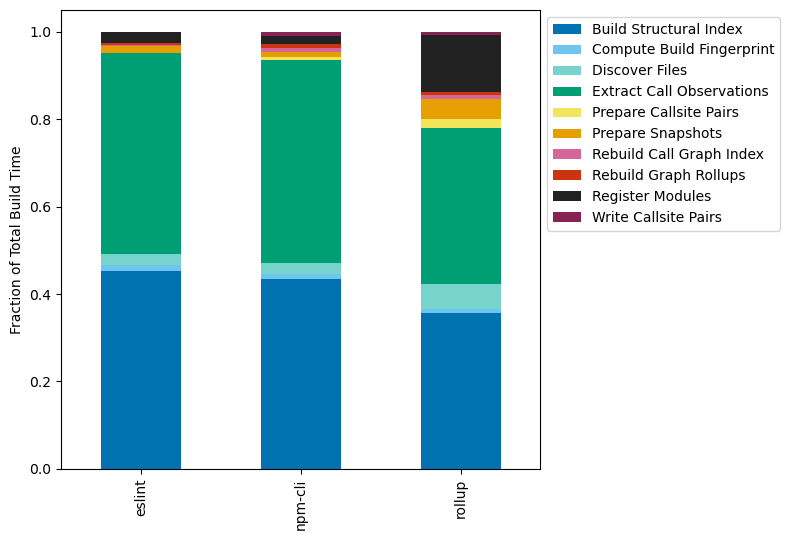

In [81]:
timing_phases_df = df_section(totals_df, "Timing").drop(columns=["Build Total Time", "Build Wall Time", "Diagnostic Classification"], errors="ignore")
timing_phases_df = timing_phases_df.div(timing_phases_df.sum(axis=1), axis=0)

timing_phases_df.plot( kind="bar", stacked=True, colormap=cmap, figsize=(8, 5.5))
plt.legend(bbox_to_anchor=(1, 1), loc="upper left")
plt.xlabel("")
plt.ylabel("Fraction of Total Build Time")
plt.tight_layout()
plt.show()

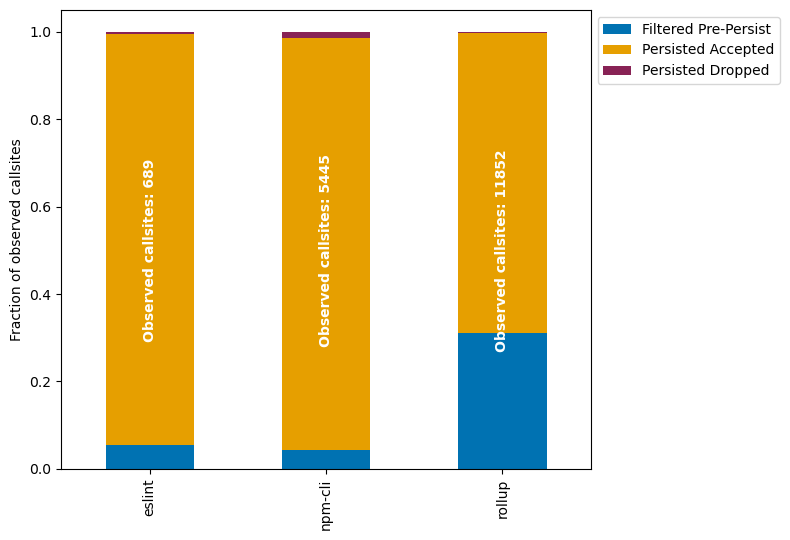

In [82]:
observed_callsites = df_section(totals_df, "Callsites")["Observed Syntactic Callsites"]

callsites_df = df_section(totals_df, "Callsites").drop(columns=["Observed Syntactic Callsites", "Persisted Callsites"])
callsites_df = callsites_df.div(callsites_df.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(8,5.5))

callsites_df.plot( kind="bar", stacked=True, colormap=cmap, ax=ax)

for i, (repo, value) in enumerate(observed_callsites.items()):
    ax.text(i, 0.5, f"Observed callsites: {int(value)}", rotation=90, ha="center", va="center", fontsize=10, fontweight="bold", color="white")

plt.legend(bbox_to_anchor=(1, 1), loc="upper left")
plt.xlabel("")
plt.ylabel("Fraction of observed callsites")
plt.tight_layout()
plt.show()

In [83]:
callsites_df

metric,Filtered Pre-Persist,Persisted Accepted,Persisted Dropped
repo,,,
eslint,0.053701,0.941945,0.004354
npm-cli,0.042608,0.943985,0.013407
rollup,0.310918,0.685370,0.003712


## Language breakdown

In [86]:
languages_pivot = languages_df.pivot(
    index=["repo","language"],
    columns=["section","metric"],
    values="value")
languages_pivot

section            Call Materialization                       \
metric                   Callsite Pairs Finalized Call Edges   
repo    language                                               
eslint  javascript                  649                  648   
        typescript                    0                    0   
npm-cli javascript                 3770                 3765   
        python                     1370                 1370   
rollup  javascript                 5984                 5984   
        typescript                 2378                 2336   

section                       Callsites                               \
metric             Filtered Pre-Persist Observed Syntactic Callsites   
repo    language                                                       
eslint  javascript                   37                          689   
        typescript                    0                            0   
npm-cli javascript                  222                         4050   
        python                       10                         1395   
rollup  javascript                 3506                         9493   
        typescript                  179                         2359   

section                                                                      \
metric             Persisted Accepted Persisted Callsites Persisted Dropped   
repo    language                                                              
eslint  javascript                649                 652                 3   
        typescript                  0                   0                 0   
npm-cli javascript               3770                3828                58   
        python                   1370                1385                15   
rollup  javascript               5984                5987                 3   
        typescript               2139                2180                41   

section                  Pre-Persist Filter                            \
metric             Accepted Outside In-Repo Invalid Observation Shape   
repo    language                                                        
eslint  javascript                        0                         0   
        typescript                        0                         0   
npm-cli javascript                        0                         0   
        python                            0                         0   
rollup  javascript                        0                         0   
        typescript                        0                         0   

section                                                 \
metric             Likely Dynamic Dispatch Or Indirect   
repo    language                                         
eslint  javascript                                   1   
        typescript                                   0   
npm-cli javascript                                   2   
        python                                       0   
rollup  javascript                                   1   
        typescript                                  38   

section                                                                     \
metric             Likely External Dependency Likely Parser Extraction Gap   
repo    language                                                             
eslint  javascript                          0                            3   
        typescript                          0                            0   
npm-cli javascript                          0                            0   
        python                              0                            0   
rollup  javascript                          0                            0   
        typescript                          0                            6   

section                                                                        \
metric             Likely Standard Library Or Builtin Likely Unindexed Symbol   
repo    language

In [ ]:
observed_callsites = languages_pivot.xs("Callsites", axis=1, level="section")["Observed Syntactic Callsites"]

callsites_df = languages_pivot.xs("Callsites", axis=1, level="section").drop(columns=["Observed Syntactic Callsites", "Persisted Callsites"])
callsites_df = callsites_df.div(callsites_df.sum(axis=1), axis=0)
callsites_df = callsites_df.sort_index(level="repo")

all_repos = callsites_df.index.get_level_values("repo").unique()

java_df = callsites_df.xs("java", level="language").reindex(all_repos, fill_value=0)
javascript_df = callsites_df.xs("javascript", level="language").reindex(all_repos, fill_value=0)
typescript_df = callsites_df.xs("typescript", level="language").reindex(all_repos, fill_value=0)
python_df = callsites_df.xs("python", level="language").reindex(all_repos, fill_value=0)

java_callsites = observed_callsites.xs("java", level="language").reindex(all_repos, fill_value=0)
javascript_callsites = observed_callsites.xs("javascript", level="language").reindex(all_repos, fill_value=0)
typescript_callsites = observed_callsites.xs("typescript", level="language").reindex(all_repos, fill_value=0)
python_callsites = observed_callsites.xs("python", level="language").reindex(all_repos, fill_value=0)

fig, axes = plt.subplots(2,2, figsize=(13,10), sharey=True)

java_df.plot(kind="bar", stacked=True, colormap=cmap, ax=axes[0,0], legend=False)
javascript_df.plot(kind="bar", stacked=True, colormap=cmap, ax=axes[0,1])
typescript_df.plot(kind="bar", stacked=True, colormap=cmap, ax=axes[1,0], legend=False)
python_df.plot(kind="bar", stacked=True, colormap=cmap, ax=axes[1,1], legend=False)

for i, (repo, value) in enumerate(java_callsites.items()):
    axes[0,0].text(i, 0.5, f"Observed callsites: {int(value):,}", rotation=90, ha="center", va="center", fontsize=10, fontweight="bold", color="white")

for i, (repo, value) in enumerate(javascript_callsites.items()):
    axes[0,1].text(i, 0.5, f"Observed callsites: {int(value):,}", rotation=90, ha="center", va="center", fontsize=10, fontweight="bold", color="white")

for i, (repo, value) in enumerate(typescript_callsites.items()):
    axes[1,0].text(i, 0.5, f"Observed callsites: {int(value):,}", rotation=90, ha="center", va="center", fontsize=10, fontweight="bold", color="white")

for i, (repo, value) in enumerate(python_callsites.items()):
    axes[1,1].text(i, 0.5, f"Observed callsites: {int(value):,}", rotation=90, ha="center", va="center", fontsize=10, fontweight="bold", color="white")

axes[0,0].set_title("Java")
axes[0,1].set_title("Javascript")
axes[1,0].set_title("Typescript")
axes[1,1].set_title("Python")

for ax in axes.flat: ax.set_xlabel("")
axes[0,0].set_ylabel("Fraction of observed callsites")
axes[0,1].legend(bbox_to_anchor=(1,1), loc="upper left")

plt.tight_layout()
plt.show()

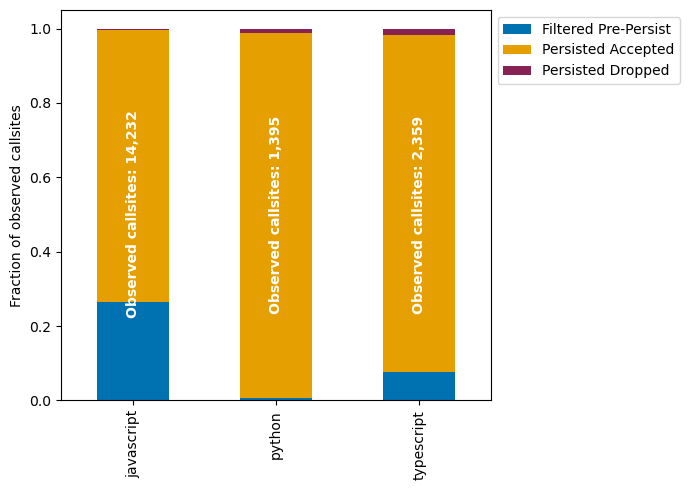

In [88]:
callsites_raw_df = languages_pivot.groupby(level="language").sum()
callsites_counts = callsites_raw_df.xs("Callsites", axis=1, level="section")["Observed Syntactic Callsites"]

callsites_df = languages_pivot.groupby(level="language").sum()
callsites_df = callsites_df.xs("Callsites", axis=1, level="section").drop(columns=["Observed Syntactic Callsites", "Persisted Callsites"])
callsites_df = callsites_df.div(callsites_df.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(7, 5))

callsites_df.plot( kind="bar", stacked=True, colormap=cmap, ax=ax)

for i, (lang, value) in enumerate(callsites_counts.items()):
    ax.text(i, 0.5, f"Observed callsites: {int(value):,}", rotation=90, ha="center", va="center", fontsize=10, fontweight="bold", color="white")

ax.legend(bbox_to_anchor=(1,1), loc="upper left")
ax.set_xlabel("")
ax.set_ylabel("Fraction of observed callsites")

plt.tight_layout()
plt.show()

In [89]:
callsites_raw_df

section    Call Materialization                                 Callsites  \
metric           Callsite Pairs Finalized Call Edges Filtered Pre-Persist   
language                                                                    
javascript                10403                10397                 3765   
python                     1370                 1370                   10   
typescript                 2378                 2336                  179   

section                                                     \
metric     Observed Syntactic Callsites Persisted Accepted   
language                                                     
javascript                        14232              10403   
python                             1395               1370   
typescript                         2359               2139   

section                                                Pre-Persist Filter  \
metric     Persisted Callsites Persisted Dropped Accepted Outside In-Repo   
language                                                                    
javascript               10467                64                        0   
python                    1385                15                        0   
typescript                2180                41                        0   

section                                                                   \
metric     Invalid Observation Shape Likely Dynamic Dispatch Or Indirect   
language                                                                   
javascript                         0                                   4   
python                             0                                   0   
typescript                         0                                  38   

section                                                             \
metric     Likely External Dependency Likely Parser Extraction Gap   
language                                                             
javascript                          0                            3   
python                              0                            0   
typescript                          0                            6   

section                                                                \
metric     Likely Standard Library Or Builtin Likely Unindexed Symbol   
language                                                                
javascript                                  0                    3758   
python                                      0                      10   
typescript                                  0                     135   

section                                      Structure                
metric     Unclassified No In-Repo Candidate     Edges  Files  Nodes  
language                                                              
javascript                                 0     28207  15079  27671  
python                                     0      2824     58   1446  
typescript                                 0      6505    381   2512

In [90]:
callsites_df

metric,Filtered Pre-Persist,Persisted Accepted,Persisted Dropped
language,,,
javascript,0.264545,0.730958,0.004497
python,0.007168,0.982079,0.010753
typescript,0.075880,0.906740,0.017380


## Scope breakdown

In [ ]:
scopes_pivot = scopes_df.pivot(
    index=["repo","scope"],
    columns=["section","metric"],
    values="value")
scopes_pivot

section                Call Materialization                       \
metric                       Callsite Pairs Finalized Call Edges   
repo         scope                                                 
airbyte      Non-Tests                14377                13537   
             Tests                      605                  605   
commons-lang Non-Tests                 3401                 3401   
             Tests                     2051                 2051   
eslint       Non-Tests                  624                  623   
             Tests                       15                   15   
guava        Non-Tests                23517                23502   
             Tests                    11905                11905   
npm-cli      Non-Tests                 4771                 4756   
             Tests                      129                  129   
pydantic     Non-Tests                 1594                 1594   
             Tests                     1123                 1114   
rollup       Non-Tests                 2397                 2355   
             Tests                     5925                 5925   
sympy        Non-Tests                25205                25148   
             Tests                    36468                35974   
vscode       Non-Tests               152896               151224   
             Tests                    23960                23947   
webpack      Non-Tests                 2809                 2795   
             Tests                      380                  380   

section                           Callsites                               \
metric                 Filtered Pre-Persist Observed Syntactic Callsites   
repo         scope                                                         
airbyte      Non-Tests                  341                        15012   
             Tests                        5                          614   
commons-lang Non-Tests                    7                         3403   
             Tests                      198                         2289   
eslint       Non-Tests                   33                          670   
             Tests                        4                           19   
guava        Non-Tests                  177                        23556   
             Tests                     1089                        13083   
npm-cli      Non-Tests                  373                         5311   
             Tests                        0                          134   
pydantic     Non-Tests                  205                         1837   
             Tests                      192                         1426   
rollup       Non-Tests                  201                         2404   
             Tests                     3499                         9448   
sympy        Non-Tests                 2775                        27951   
             Tests                     8272                        44712   
vscode       Non-Tests                 9697                       132767   
             Tests                      511                        22684   
webpack      Non-Tests                  151                         2973   
             Tests                        5                          395   

section                                                        \
metric                 Persisted Accepted Persisted Callsites   
repo         scope                                              
airbyte      Non-Tests              14377               14671   
             Tests                    605                 609   
commons-lang Non-Tests               3387                3396   
             Tests                   2051                2091   
eslint       Non-Tests                624                 637   
             Tests                     15                  15   
guava        Non-Tests              23249               23379   
             Tests                  

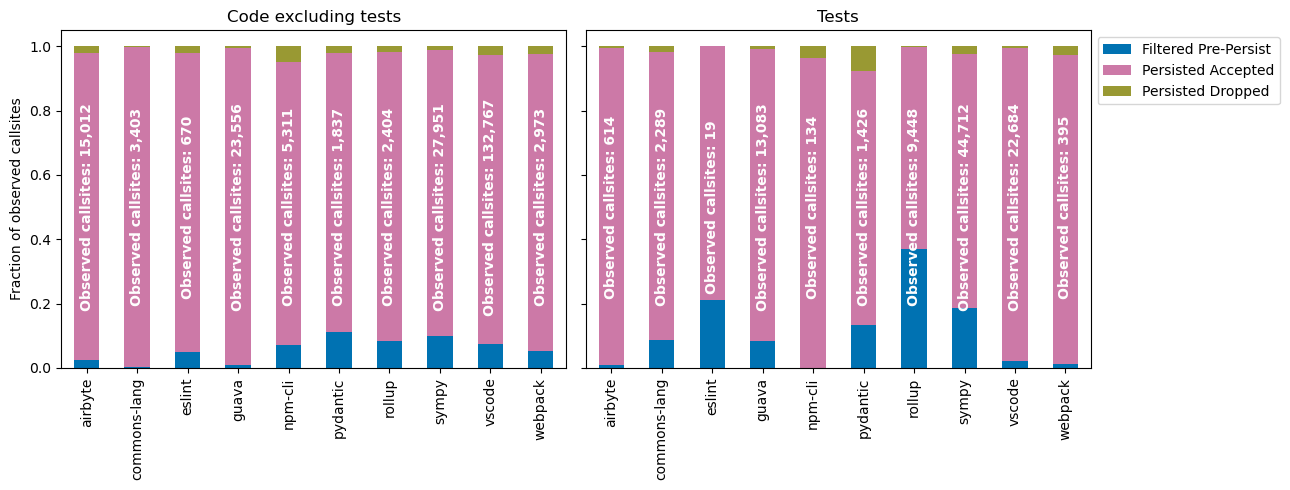

In [ ]:
callsites_counts = scopes_pivot.xs("Callsites", axis=1, level="section")["Observed Syntactic Callsites"]
counts_non_tests = callsites_counts.xs("Non-Tests", level="scope")
counts_tests = callsites_counts.xs("Tests", level="scope")

callsites_df = scopes_pivot.xs("Callsites", axis=1, level="section").drop(columns=["Observed Syntactic Callsites", "Persisted Callsites"])
callsites_df = callsites_df.div(callsites_df.sum(axis=1), axis=0)
callsites_df = callsites_df.sort_index(level="repo")

non_test_df = callsites_df.xs("Non-Tests", level="scope")
tests_df = callsites_df.xs("Tests", level="scope")

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

non_test_df.plot(kind="bar", stacked=True, colormap=cmap, ax=axes[0],legend=False)
tests_df.plot(kind="bar", stacked=True, colormap=cmap, ax=axes[1])

for i, (repo, value) in enumerate(counts_non_tests.items()):
    axes[0].text(i, 0.5, f"Observed callsites: {int(value):,}", rotation=90, ha="center", va="center", fontsize=10, fontweight="bold", color="white")

for i, (repo, value) in enumerate(counts_tests.items()):
    axes[1].text(i, 0.5, f"Observed callsites: {int(value):,}", rotation=90, ha="center", va="center", fontsize=10, fontweight="bold", color="white")
    
axes[0].set_title("Code excluding tests")
axes[1].set_title("Tests")
axes[0].set_xlabel("")
axes[0].set_ylabel("Fraction of observed callsites")
axes[1].set_ylabel("")
axes[1].set_xlabel("")
axes[1].legend(bbox_to_anchor=(1,1),loc="upper left")
plt.tight_layout()
plt.show()

## Diagnostics

In [ ]:
df_section(totals_df, "Pre-Persist Filter")

metric,Accepted Outside In-Repo,Invalid Observation Shape,Likely Dynamic Dispatch Or Indirect,Likely External Dependency,Likely Parser Extraction Gap,Likely Standard Library Or Builtin,Likely Unindexed Symbol,Unclassified No In-Repo Candidate
repo,,,,,,,,
airbyte,0.0,0.0,0.0,0.0,87.0,0.0,259.0,0.0
commons-lang,0.0,0.0,0.0,0.0,185.0,0.0,20.0,0.0
eslint,0.0,0.0,1.0,0.0,3.0,0.0,33.0,0.0
guava,0.0,0.0,0.0,0.0,1256.0,0.0,10.0,0.0
npm-cli,0.0,0.0,2.0,0.0,0.0,0.0,371.0,0.0
pydantic,0.0,0.0,0.0,0.0,0.0,0.0,397.0,0.0
rollup,0.0,0.0,39.0,0.0,19.0,0.0,3642.0,0.0
sympy,0.0,0.0,0.0,0.0,11.0,0.0,11036.0,0.0
vscode,0.0,0.0,104.0,0.0,453.0,0.0,9651.0,0.0


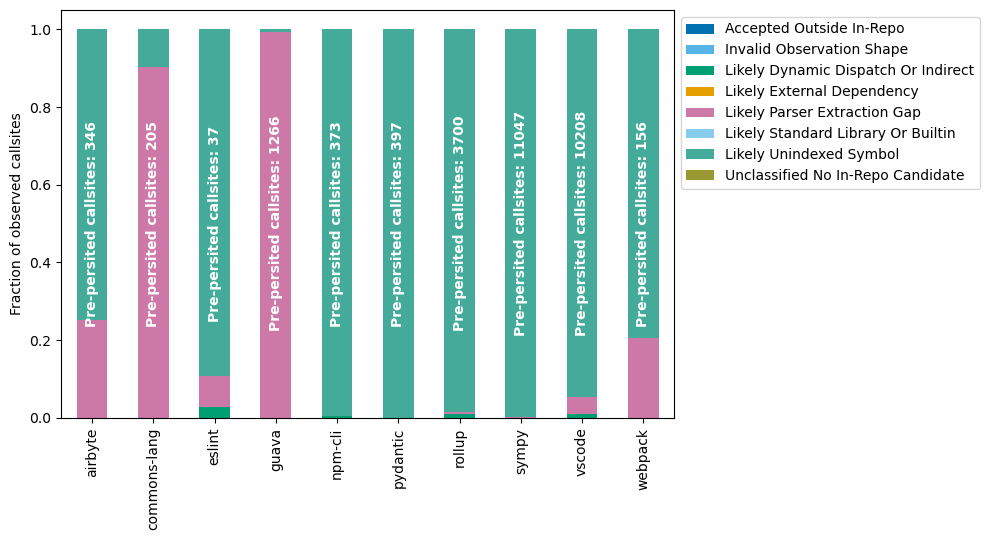

In [ ]:
pre_persist = df_section(totals_df, "Callsites")["Filtered Pre-Persist"]

pre_persist_df = df_section(totals_df, "Pre-Persist Filter")
pre_persist_df = pre_persist_df.div(pre_persist_df.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(10,5.5))

pre_persist_df.plot( kind="bar", stacked=True, colormap=cmap, ax=ax)

for i, (repo, value) in enumerate(pre_persist.items()):
    ax.text(i, 0.5, f"Pre-persited callsites: {int(value)}", rotation=90, ha="center", va="center", fontsize=10, fontweight="bold", color="white")

plt.legend(bbox_to_anchor=(1, 1), loc="upper left")
plt.xlabel("")
plt.ylabel("Fraction of observed callsites")
plt.tight_layout()
plt.show()